# Poster figures — interactive

Each figure is independent — run Setup + Load Data once, then edit/re-run just the figure cell you're iterating on. Each figure cell ends with `plt.savefig(...)`.

**Data status (2026-07-30):** the `COEF_SEED` confound found in the first multi-seed pass has been fixed — spindle data was regenerated per `COEF_SEED` (`computefrcenterout_multiseed.py`) and inference re-run with correctly matched data (`multi_seed_inference_matched.py`). All 20 seeds are now a valid comparison; no more filtering needed.

## Setup

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

CENTEROUT_DIR = "/home/sydneyez/sydneyez/ProprioceptiveIllusions/dataexp/centerout"
RESULTS_CSV = os.path.join(CENTEROUT_DIR, "multi_seed_results_matched.csv")
RANKING_CSV = os.path.join(CENTEROUT_DIR, "multi_seed_ranking_matched.csv")
TRAJECTORY_CSV = os.path.join(CENTEROUT_DIR, "multi_seed_trajectory.csv")

DIR_COLORS = {
    "0_right": "#e74c3c", "45_fwd_right": "#e67e22", "90_forward": "#f1c40f",
    "135_fwd_left": "#2ecc71", "180_left": "#1abc9c", "225_back_left": "#3498db",
    "270_backward": "#9b59b6", "315_back_right": "#e91e63",
}
DIRECTIONS_ORDERED = ["0_right", "45_fwd_right", "90_forward", "135_fwd_left",
                       "180_left", "225_back_left", "270_backward", "315_back_right"]

## Load data

In [2]:
df = pd.read_csv(RESULTS_CSV)
print(f"Loaded {len(df)} rows, {df['seed'].nunique()} seeds, {df['direction'].nunique()} grid points")

traj_df = pd.read_csv(TRAJECTORY_CSV)
print(f"Loaded {len(traj_df)} trajectory rows, {traj_df['seed'].nunique()} seeds, "
      f"{traj_df['direction'].nunique()} directions, {traj_df['frame_idx'].nunique()} frames")
df.head()

Loaded 1600 rows, 20 seeds, 80 grid points
Loaded 19200 trajectory rows, 20 seeds, 8 directions, 120 frames


,seed,coef_seed,train_seed,direction,true_x,true_y,true_z,pred_x,pred_y,pred_z,l2_at_peak,sh_elv_rmse,sh_rot_rmse,elbow_rmse,wrist_rmse,mean_l2
0,0_0,0,0,0_right,51.353928,-6.801852,-2.930428,49.748573,-6.342548,-2.829251,1.672830,1.112081,1.314179,1.310164,0.706875,1.002585
1,0_0,0,0,135_fwd_left,34.282860,0.269216,-2.930429,32.907740,0.968649,-2.903030,1.543019,1.185735,0.581495,0.838288,0.557826,0.835778
2,0_0,0,0,180_left,31.353933,-6.801854,-2.930426,30.295984,-7.556606,-3.476090,1.409488,1.170183,0.442158,0.733977,0.556591,0.830060
3,0_0,0,0,225_back_left,34.282860,-13.872919,-2.930426,33.760056,-13.613640,-2.927382,0.583575,1.199069,0.873334,0.651800,0.508102,0.743879
4,0_0,0,0,270_backward,41.353928,-16.801853,-2.930425,40.444107,-17.555014,-3.253959,1.224622,1.009462,0.850730,0.809569,0.527559,0.795806


## Figure 1: Heatmap (left-panel style, mean L2 across all 20 seeds)

In [3]:
mean_by_point = df.groupby("direction").agg(
    true_x=("true_x", "mean"), true_y=("true_y", "mean"),
    mean_l2=("l2_at_peak", "mean"), std_l2=("l2_at_peak", "std"),
).reset_index()
mean_by_point.head()

,direction,true_x,true_y,mean_l2,std_l2
0,0_right,51.353928,-6.801852,1.636483,0.626709
1,135_fwd_left,34.282860,0.269216,1.114844,0.368507
2,180_left,31.353933,-6.801854,1.149673,0.444377
3,225_back_left,34.282860,-13.872919,1.042926,0.362384
4,270_backward,41.353928,-16.801853,0.837617,0.372360


Saved /home/sydneyez/sydneyez/ProprioceptiveIllusions/dataexp/centerout/poster_heatmap_leftpanel.png


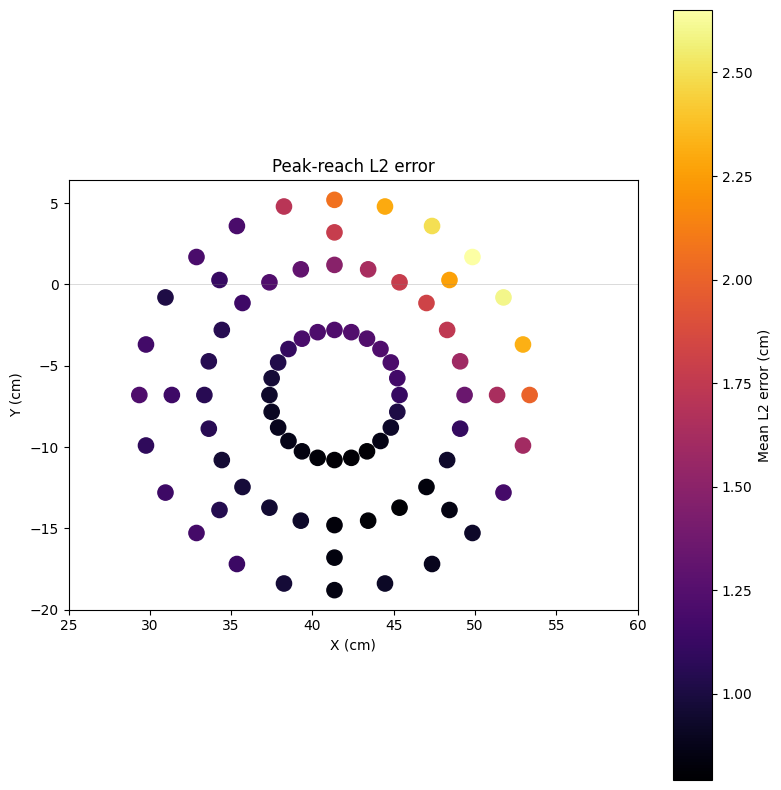

In [16]:
# --- Figure 1 plot: edit freely ---
fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(mean_by_point["true_x"], mean_by_point["true_y"],
                 c=mean_by_point["mean_l2"], cmap="inferno", s=120)
ax.set_xlabel("X (cm)")
plt.xlim(25, 60)
ax.set_ylabel("Y (cm)")
ax.set_title(f"Peak-reach L2 error")
ax.set_aspect("equal")
ax.axhline(0, c="gray", linewidth=0.5, alpha=0.4)
ax.axvline(0, c="gray", linewidth=0.5, alpha=0.4)
plt.colorbar(sc, ax=ax, label="Mean L2 error (cm)")
plt.tight_layout()

out1 = os.path.join(CENTEROUT_DIR, "poster_heatmap_leftpanel.png")
plt.savefig(out1, dpi=150, bbox_inches="tight")
print(f"Saved {out1}")
plt.show()

## Figure 2: Arrow plot (Fig. 3a-style)

Tail = predicted location, head = true target location, at peak-reach frame. Gray = 20 individual seeds, black = across-seed mean.

Saved /home/sydneyez/sydneyez/ProprioceptiveIllusions/dataexp/centerout/poster_arrow_plot.png


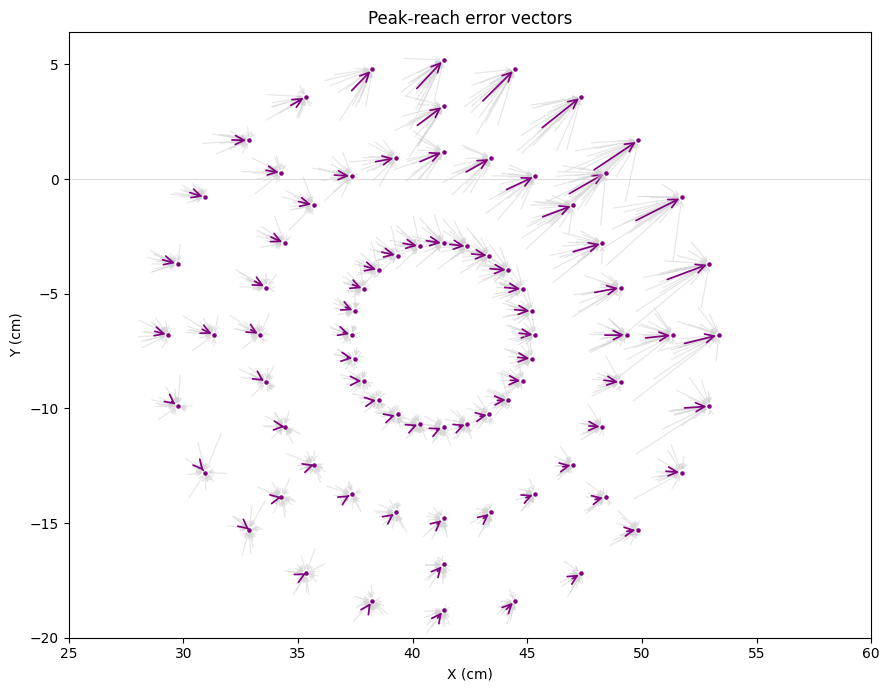

In [30]:
# --- Figure 2 plot: edit freely ---
fig, ax = plt.subplots(figsize=(9, 9))
SHOW_INDIVIDUAL_SEEDS = True

for direction, group in df.groupby("direction"):
    true_x = group["true_x"].mean()
    true_y = group["true_y"].mean()

    if SHOW_INDIVIDUAL_SEEDS:
        for _, row in group.iterrows():
            ax.annotate("", xy=(true_x, true_y), xytext=(row["pred_x"], row["pred_y"]),
                        arrowprops=dict(arrowstyle="->", color="lightgray",
                                         lw=0.8, alpha=0.6, mutation_scale=8))

    mean_pred_x = group["pred_x"].mean()
    mean_pred_y = group["pred_y"].mean()
    ax.annotate("", xy=(true_x, true_y), xytext=(mean_pred_x, mean_pred_y),
                arrowprops=dict(arrowstyle="->", color="purple", lw=1.25, mutation_scale=16))
    ax.scatter([true_x], [true_y], c="purple", s=5, zorder=5)

ax.set_xlabel("X (cm)")
plt.xlim(25, 60)
ax.set_ylabel("Y (cm)")
ax.set_title(f"Peak-reach error vectors")
ax.set_aspect("equal")
ax.axhline(0, c="gray", linewidth=0.5, alpha=0.4)
ax.axvline(0, c="gray", linewidth=0.5, alpha=0.4)
plt.tight_layout()

out2 = os.path.join(CENTEROUT_DIR, "poster_arrow_plot.png")
plt.savefig(out2, dpi=150, bbox_inches="tight")
print(f"Saved {out2}")
plt.show()

## Figure 3: Truth vs. predicted trajectories (reach phase only)

Frames 396:516, centered at reach onset. Left panel: truth (one line per direction, colored). Right panel: predicted — 20 individual-seed lines (light) + bold mean line, per direction.

/tmp/ipykernel_2384112/2257192866.py:36: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax_true.scatter(0, 0, c=color, s=30, zorder=5, edgecolors="black", linewidth=0.4)


Saved /home/sydneyez/sydneyez/ProprioceptiveIllusions/dataexp/centerout/poster_trajectory_plot.png


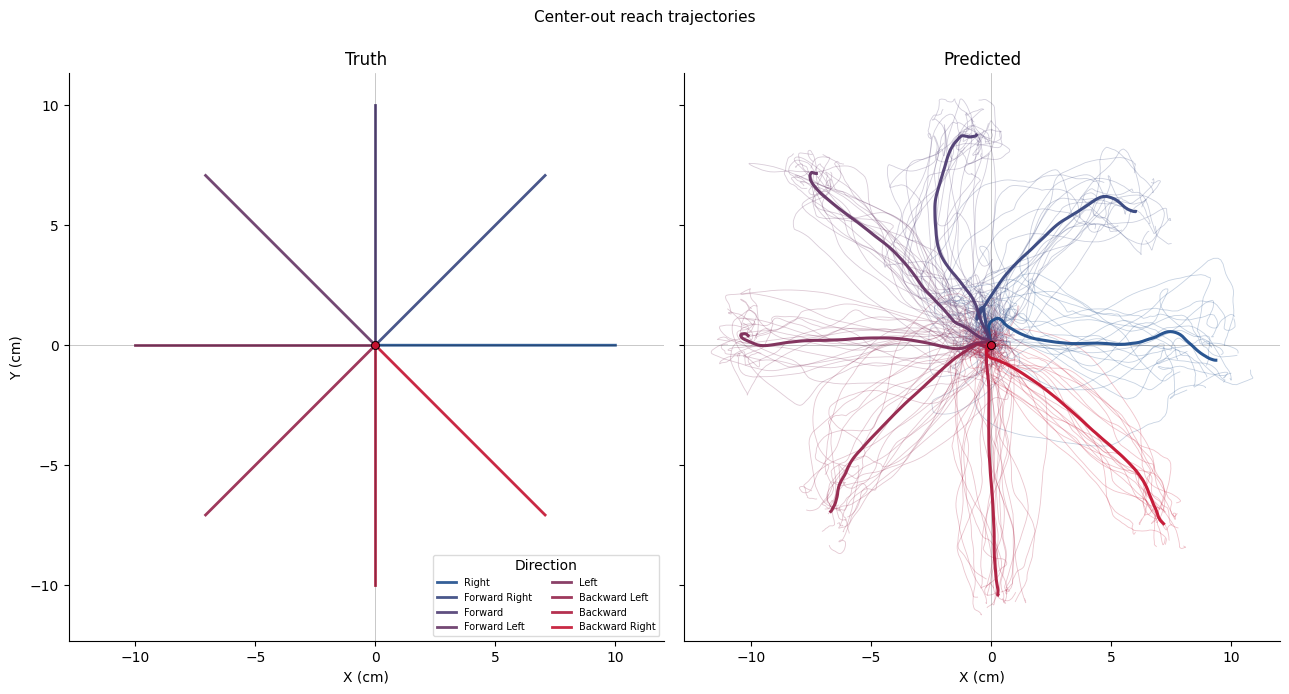

In [29]:
# --- Figure 3 plot: edit freely (line widths, alpha, colors, etc.) ---
from matplotlib.colors import LinearSegmentedColormap

DIRECTIONS_ORDERED = ["0_right", "45_fwd_right", "90_forward", "135_fwd_left",
                       "180_left", "225_back_left", "270_backward", "315_back_right"]

BARNARD_BLUE = "#1e4d8c"  # approx -- verify against Barnard brand guide
CMU_RED = "#C41230"       # documented CMU brand red

_bcr_cmap = LinearSegmentedColormap.from_list("barnard_to_cmu", [BARNARD_BLUE, CMU_RED], N=256)
DIR_COLORS = {d: _bcr_cmap(x) for d, x in zip(DIRECTIONS_ORDERED, np.linspace(0, 1, len(DIRECTIONS_ORDERED)))}

DIRECTION_LABELS = {
    "0_right": "Right",
    "45_fwd_right": "Forward Right",
    "90_forward": "Forward",
    "135_fwd_left": "Forward Left",
    "180_left": "Left",
    "225_back_left": "Backward Left",
    "270_backward": "Backward",
    "315_back_right": "Backward Right",
}

fig, (ax_true, ax_pred) = plt.subplots(1, 2, figsize=(13, 6.5), sharex=True, sharey=True)

for direction in DIRECTIONS_ORDERED:
    color = DIR_COLORS.get(direction, "gray")
    dsub = traj_df[traj_df["direction"] == direction]
    if dsub.empty:
        continue

    # Truth: identical across seeds (analytic-FK labels don't depend on coef_seed) -- use seed 0_9 as representative
    truth_one = dsub[dsub["seed"] == "0_9"].sort_values("frame_idx")
    ax_true.plot(truth_one["true_x"], truth_one["true_y"], c=color, linewidth=2.0,
                 alpha=0.9, label=DIRECTION_LABELS.get(direction, direction.replace("_", " ")))
    ax_true.scatter(0, 0, c=color, s=30, zorder=5, edgecolors="black", linewidth=0.4)

    # Predicted: individual seeds light, mean bold
    for seed, sgroup in dsub.groupby("seed"):
        sgroup = sgroup.sort_values("frame_idx")
        ax_pred.plot(sgroup["pred_x"], sgroup["pred_y"], c=color, linewidth=0.6,
                     alpha=0.25, zorder=2)

    mean_pred = dsub.groupby("frame_idx")[["pred_x", "pred_y"]].mean().reset_index().sort_values("frame_idx")
    ax_pred.plot(mean_pred["pred_x"], mean_pred["pred_y"], color=color, linewidth=2.2,
                 alpha=0.95, zorder=4)
    ax_pred.scatter(mean_pred["pred_x"].iloc[0], mean_pred["pred_y"].iloc[0],
                     color=color, s=30, zorder=5, edgecolors="black", linewidth=0.4)

for ax, title in [(ax_true, "Truth"), (ax_pred, "Predicted")]:
    ax.axhline(0, c="black", linewidth=0.5, alpha=0.3)
    ax.axvline(0, c="black", linewidth=0.5, alpha=0.3)
    ax.set_xlabel("X (cm)")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.spines[["top", "right"]].set_visible(False)

ax_true.set_ylabel("Y (cm)")
ax_true.legend(fontsize=7, loc="lower right", ncol=2, framealpha=0.7, title="Direction")
fig.suptitle("Center-out reach trajectories", fontsize=11, y=1.02)
plt.tight_layout()

out3 = os.path.join(CENTEROUT_DIR, "poster_trajectory_plot.png")
plt.savefig(out3, dpi=150, bbox_inches="tight")
print(f"Saved {out3}")
plt.show()

Saved /home/sydneyez/sydneyez/ProprioceptiveIllusions/dataexp/centerout/poster_trajectory_plot_timegradient.png


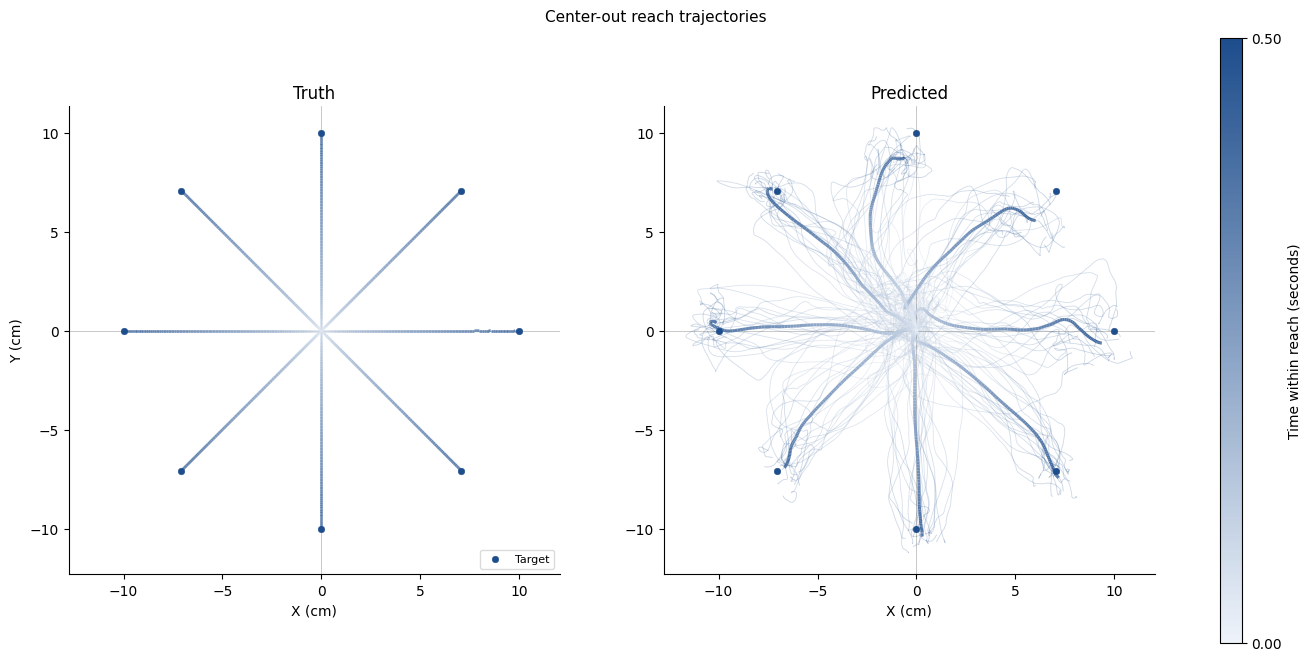

In [47]:
# --- Figure 3b: time-gradient comparison, all directions overlaid, single color ramp ---
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib.cm as cm

SAMPLE_RATE = 240  # restated here for clarity
N_REACH = 120
reach_times = np.arange(N_REACH) / SAMPLE_RATE  # 0.00 -> ~0.496 s within the reach window

# Single-hue "gets darker over time" ramp, pale -> full Barnard blue
_time_cmap = LinearSegmentedColormap.from_list("time_gradient", ["#eef3fa", BARNARD_BLUE], N=256)
_time_norm = Normalize(vmin=reach_times[0], vmax=reach_times[-1])


def _add_gradient_line(ax, x, y, times, cmap, norm, linewidth, alpha, zorder):
    """Draw a line whose color darkens along its length according to `times`."""
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=linewidth,
                         alpha=alpha, zorder=zorder)
    lc.set_array(times[:-1])
    ax.add_collection(lc)
    return lc


fig = plt.figure(figsize=(13, 6.5), constrained_layout=True)
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.045], wspace=0.15)
ax_true = fig.add_subplot(gs[0])
ax_pred = fig.add_subplot(gs[1], sharex=ax_true, sharey=ax_true)
cax = fig.add_subplot(gs[2])

target_handle = None
for direction in DIRECTIONS_ORDERED:
    dsub = traj_df[traj_df["direction"] == direction]
    if dsub.empty:
        continue

    # Truth: identical across seeds (analytic-FK labels don't depend on coef_seed) -- seed 0_9 as representative
    truth_one = dsub[dsub["seed"] == "0_9"].sort_values("frame_idx")
    tx, ty = truth_one["true_x"].values, truth_one["true_y"].values
    _add_gradient_line(ax_true, tx, ty, reach_times, _time_cmap, _time_norm,
                        linewidth=2.0, alpha=0.9, zorder=3)

    # Predicted: individual seeds faded, mean bold -- all sharing the same time ramp
    for seed, sgroup in dsub.groupby("seed"):
        sgroup = sgroup.sort_values("frame_idx")
        _add_gradient_line(ax_pred, sgroup["pred_x"].values, sgroup["pred_y"].values,
                            reach_times, _time_cmap, _time_norm, linewidth=0.6, alpha=0.25, zorder=2)

    mean_pred = dsub.groupby("frame_idx")[["pred_x", "pred_y"]].mean().reset_index().sort_values("frame_idx")
    px, py = mean_pred["pred_x"].values, mean_pred["pred_y"].values
    _add_gradient_line(ax_pred, px, py, reach_times, _time_cmap, _time_norm,
                        linewidth=2.2, alpha=0.95, zorder=4)

    # Only labeled point on either panel: the ground-truth target (reach endpoint)
    # -- fixed color BARNARD_BLUE for every direction, NOT the per-direction `color` variable
    target_handle = ax_true.scatter(tx[-1], ty[-1], color=BARNARD_BLUE, marker=".", s=90,
                                     zorder=6, linewidth=0.35, label="Target")
    ax_pred.scatter(tx[-1], ty[-1], color=BARNARD_BLUE, marker=".", s=90,
                     zorder=6, linewidth=0.35)

for ax, title in [(ax_true, "Truth"), (ax_pred, "Predicted")]:
    ax.axhline(0, c="black", linewidth=0.5, alpha=0.3)
    ax.axvline(0, c="black", linewidth=0.5, alpha=0.3)
    ax.set_xlabel("X (cm)")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.spines[["top", "right"]].set_visible(False)
    ax.autoscale_view()  # LineCollection needs this to update axis limits

ax_true.set_ylabel("Y (cm)")
ax_true.legend(handles=[target_handle], fontsize=8, loc="lower right", framealpha=0.7)

sm = cm.ScalarMappable(cmap=_time_cmap, norm=_time_norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax, orientation="vertical")
cbar.set_label("Time within reach (seconds)")
cbar.set_ticks([reach_times[0], reach_times[-1]])
cbar.set_ticklabels([f"{reach_times[0]:.2f}", f"{reach_times[-1]:.2f}"])

fig.suptitle("Center-out reach trajectories", fontsize=11)

out3b = os.path.join(CENTEROUT_DIR, "poster_trajectory_plot_timegradient.png")
plt.savefig(out3b, dpi=150, bbox_inches="tight")
print(f"Saved {out3b}")
plt.show()

## Figure 4: Pipeline block diagram (code-built, editable)

Matplotlib schematic (not a static image) so colors/text/layout can be tweaked directly. Green = corrected stage, tan = frozen/immutable stage.

Saved /home/sydneyez/sydneyez/ProprioceptiveIllusions/dataexp/centerout/poster_block_diagram.png


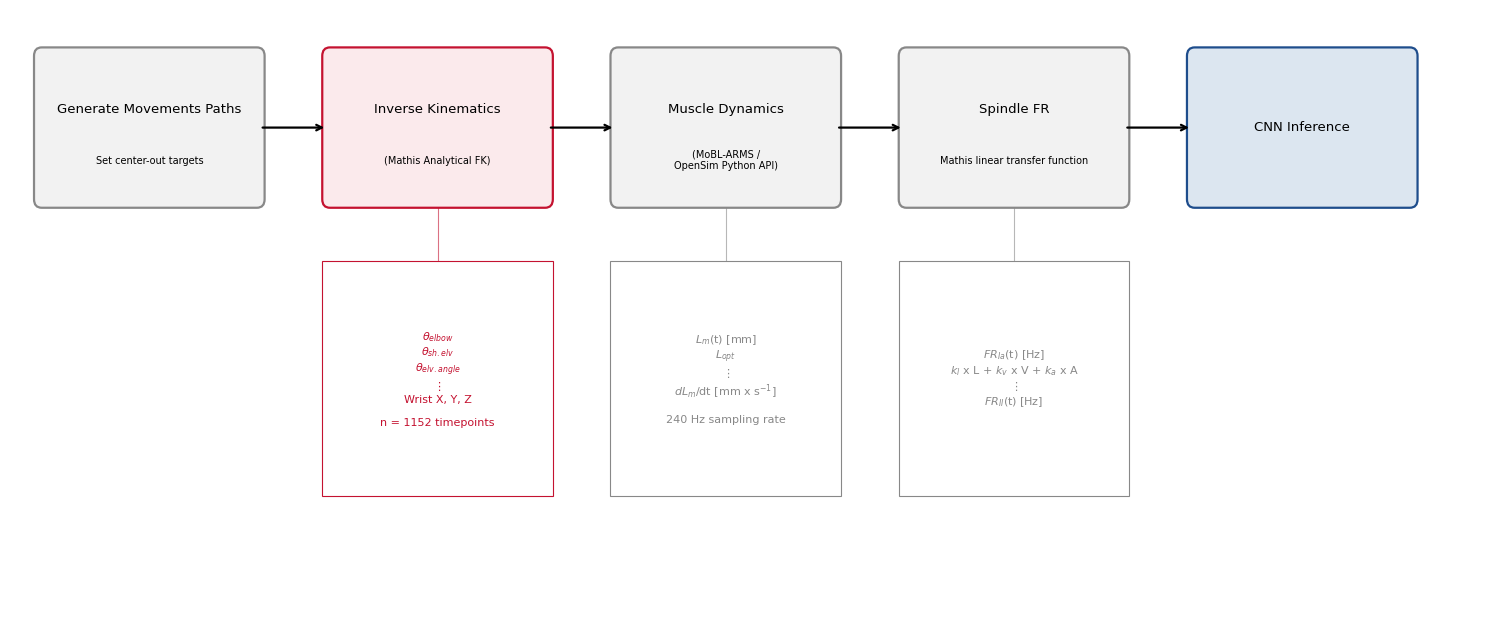

In [26]:
# --- Figure 4 plot: edit freely (box positions, colors, wording, annotation text) ---

# Parameter "matrices" -- leading dot-dot-dot (earlier/omitted variables) and
# one before each matrix's final stored value, consistently across all three.
ik_matrix = (
    r"$\theta_{elbow}$" "\n"
    r"$\theta_{sh.elv}$" "\n"
    r"$\theta_{elv.angle}$" "\n"
    r"$\vdots$" "\n"
    "Wrist X, Y, Z" "\n\n"
    "n = 1152 timepoints"
)

muscle_matrix = (
    r"$L_m$(t) [mm]" "\n"
    r"$L_{opt}$" "\n"
    r"$\vdots$" "\n"
    r"$dL_m$/dt [mm x s$^{-1}$]" "\n\n"
    "240 Hz sampling rate"
)

spindle_matrix = (
    r"$FR_{Ia}$(t) [Hz]" "\n"
    r"$k_l$ x L + $k_v$ x V + $k_a$ x A" "\n"
    r"$\vdots$" "\n"
    r"$FR_{II}$(t) [Hz]"
)

PALE_CMU_RED_FILL, CMU_RED = "#fbeaec", "#C41230"
PALE_BARNARD_BLUE_FILL, BARNARD_BLUE = "#dce6f0", "#1e4d8c"  # approx -- verify against Barnard brand guide

stages = [
    ("Generate Movements Paths", "Set center-out targets", "#f2f2f2", "#888888", None),
    ("Inverse Kinematics", "(Mathis Analytical FK)", PALE_CMU_RED_FILL, CMU_RED, ik_matrix),
    ("Muscle Dynamics", "(MoBL-ARMS /\nOpenSim Python API)", "#f2f2f2", "#888888", muscle_matrix),
    ("Spindle FR", "Mathis linear transfer function", "#f2f2f2", "#888888", spindle_matrix),
    ("CNN Inference", "", PALE_BARNARD_BLUE_FILL, BARNARD_BLUE, None),
]

fig, ax = plt.subplots(figsize=(15, 6.5))
box_w, box_h = 2.3, 1.4
gap = 0.7
y0 = 1.0
ANNOT_W, ANNOT_H = 2.3, 2.1  # uniform size, bumped slightly for the extra ellipsis line

box_centers = []

# Pass 1: boxes, titles, and matrix annotations
for i, (title, subtitle, facecolor, edgecolor, annotation) in enumerate(stages):
    x0 = i * (box_w + gap)
    box_centers.append((x0, x0 + box_w))

    box = FancyBboxPatch((x0, y0), box_w, box_h, boxstyle="round,pad=0.05,rounding_size=0.08",
                          linewidth=1.6, edgecolor=edgecolor, facecolor=facecolor, zorder=3)
    ax.add_patch(box)

    if subtitle:
        ax.text(x0 + box_w / 2, y0 + box_h * 0.62, title, ha="center", va="center",
                fontsize=9.5, zorder=4)
        ax.text(x0 + box_w / 2, y0 + box_h * 0.28, subtitle, ha="center", va="center",
                fontsize=7, zorder=4)
    else:
        ax.text(x0 + box_w / 2, y0 + box_h / 2, title, ha="center", va="center",
                fontsize=9.5, zorder=4)

    if annotation:
        ay0 = y0 - 0.6 - ANNOT_H
        annot_box = FancyBboxPatch((x0 + box_w / 2 - ANNOT_W / 2, ay0), ANNOT_W, ANNOT_H,
                                    boxstyle="square,pad=0.05", linewidth=0.8,
                                    edgecolor=edgecolor, facecolor="white", zorder=3)
        ax.add_patch(annot_box)
        ax.text(x0 + box_w / 2, ay0 + ANNOT_H / 2, annotation, ha="center", va="center",
                fontsize=8, color=edgecolor, zorder=4)
        ax.plot([x0 + box_w / 2, x0 + box_w / 2], [y0, ay0 + ANNOT_H],
                color=edgecolor, lw=0.8, alpha=0.6, zorder=2)

# Pass 2: connecting arrows, drawn on top of everything -- sharp "->" tips
for i in range(len(stages) - 1):
    x_start = box_centers[i][1]
    x_end = box_centers[i + 1][0]
    ax.annotate("", xy=(x_end, y0 + box_h / 2), xytext=(x_start, y0 + box_h / 2),
                arrowprops=dict(arrowstyle="->", color="black", lw=1.6),
                zorder=10)

ax.set_xlim(-0.3, len(stages) * (box_w + gap))
ax.set_ylim(-3.0, 2.8)
ax.axis("off")
plt.tight_layout()

out4 = os.path.join(CENTEROUT_DIR, "poster_block_diagram.png")
plt.savefig(out4, dpi=150, bbox_inches="tight")
print(f"Saved {out4}")
plt.show()

## Seed ranking

Now a valid comparison across all 20 seeds (COEF_SEED confound fixed).

In [ ]:
if os.path.exists(RANKING_CSV):
    ranking = pd.read_csv(RANKING_CSV)
    print("Seed ranking (best to worst, mean L2):")
    display(ranking[["rank", "seed", "overall_mean_l2"]])
else:
    print(f"{RANKING_CSV} not found")